In [43]:
!pip list

Package                   Version
------------------------- --------------
absl-py                   2.2.2
anyio                     4.9.0
argon2-cffi               23.1.0
argon2-cffi-bindings      21.2.0
arrow                     1.3.0
asttokens                 3.0.0
astunparse                1.6.3
async-lru                 2.0.5
attrs                     25.3.0
babel                     2.17.0
beautifulsoup4            4.13.4
bleach                    6.2.0
certifi                   2025.1.31
cffi                      1.17.1
charset-normalizer        3.4.1
click                     8.1.8
comm                      0.2.2
contourpy                 1.3.2
cycler                    0.12.1
debugpy                   1.8.14
decorator                 5.2.1
defusedxml                0.7.1
executing                 2.2.0
fastjsonschema            2.21.1
flatbuffers               25.2.10
fonttools                 4.57.0
fqdn                      1.5.1
gast                      0.6.0
google-pasta 

## Step 1: Importing libaries

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import svm
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras import callbacks
from sklearn.metrics import precision_score,recall_score,confusion_matrix,accuracy_score,classification_report

## Step 2: Data Importing and Analysis

In [45]:
data_df = pd.read_csv("heart_failure_clinical_records_dataset.csv")

In [46]:
data_df

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1,270,0
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0,271,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,278,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1,280,0


/tmp/ipykernel_20903/357169056.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=data_df["DEATH_EVENT"], palette=cols)


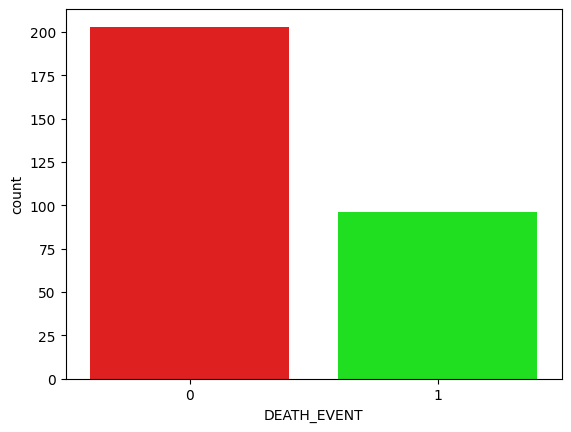

In [47]:
cols = ["#FF0000", "#00FF00"]
ax = sns.countplot(x=data_df["DEATH_EVENT"], palette=cols)

In [48]:
data_df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,299.0,60.833893,11.894809,40.0,51.0,60.0,70.0,95.0
anaemia,299.0,0.431438,0.496107,0.0,0.0,0.0,1.0,1.0
creatinine_phosphokinase,299.0,581.839465,970.287881,23.0,116.5,250.0,582.0,7861.0
diabetes,299.0,0.418060,0.494067,0.0,0.0,0.0,1.0,1.0
ejection_fraction,299.0,38.083612,11.834841,14.0,30.0,38.0,45.0,80.0
high_blood_pressure,299.0,0.351171,0.478136,0.0,0.0,0.0,1.0,1.0
platelets,299.0,263358.029264,97804.236869,25100.0,212500.0,262000.0,303500.0,850000.0
serum_creatinine,299.0,1.393880,1.034510,0.5,0.9,1.1,1.4,9.4
serum_sodium,299.0,136.625418,4.412477,113.0,134.0,137.0,140.0,148.0
sex,299.0,0.648829,0.478136,0.0,0.0,1.0,1.0,1.0


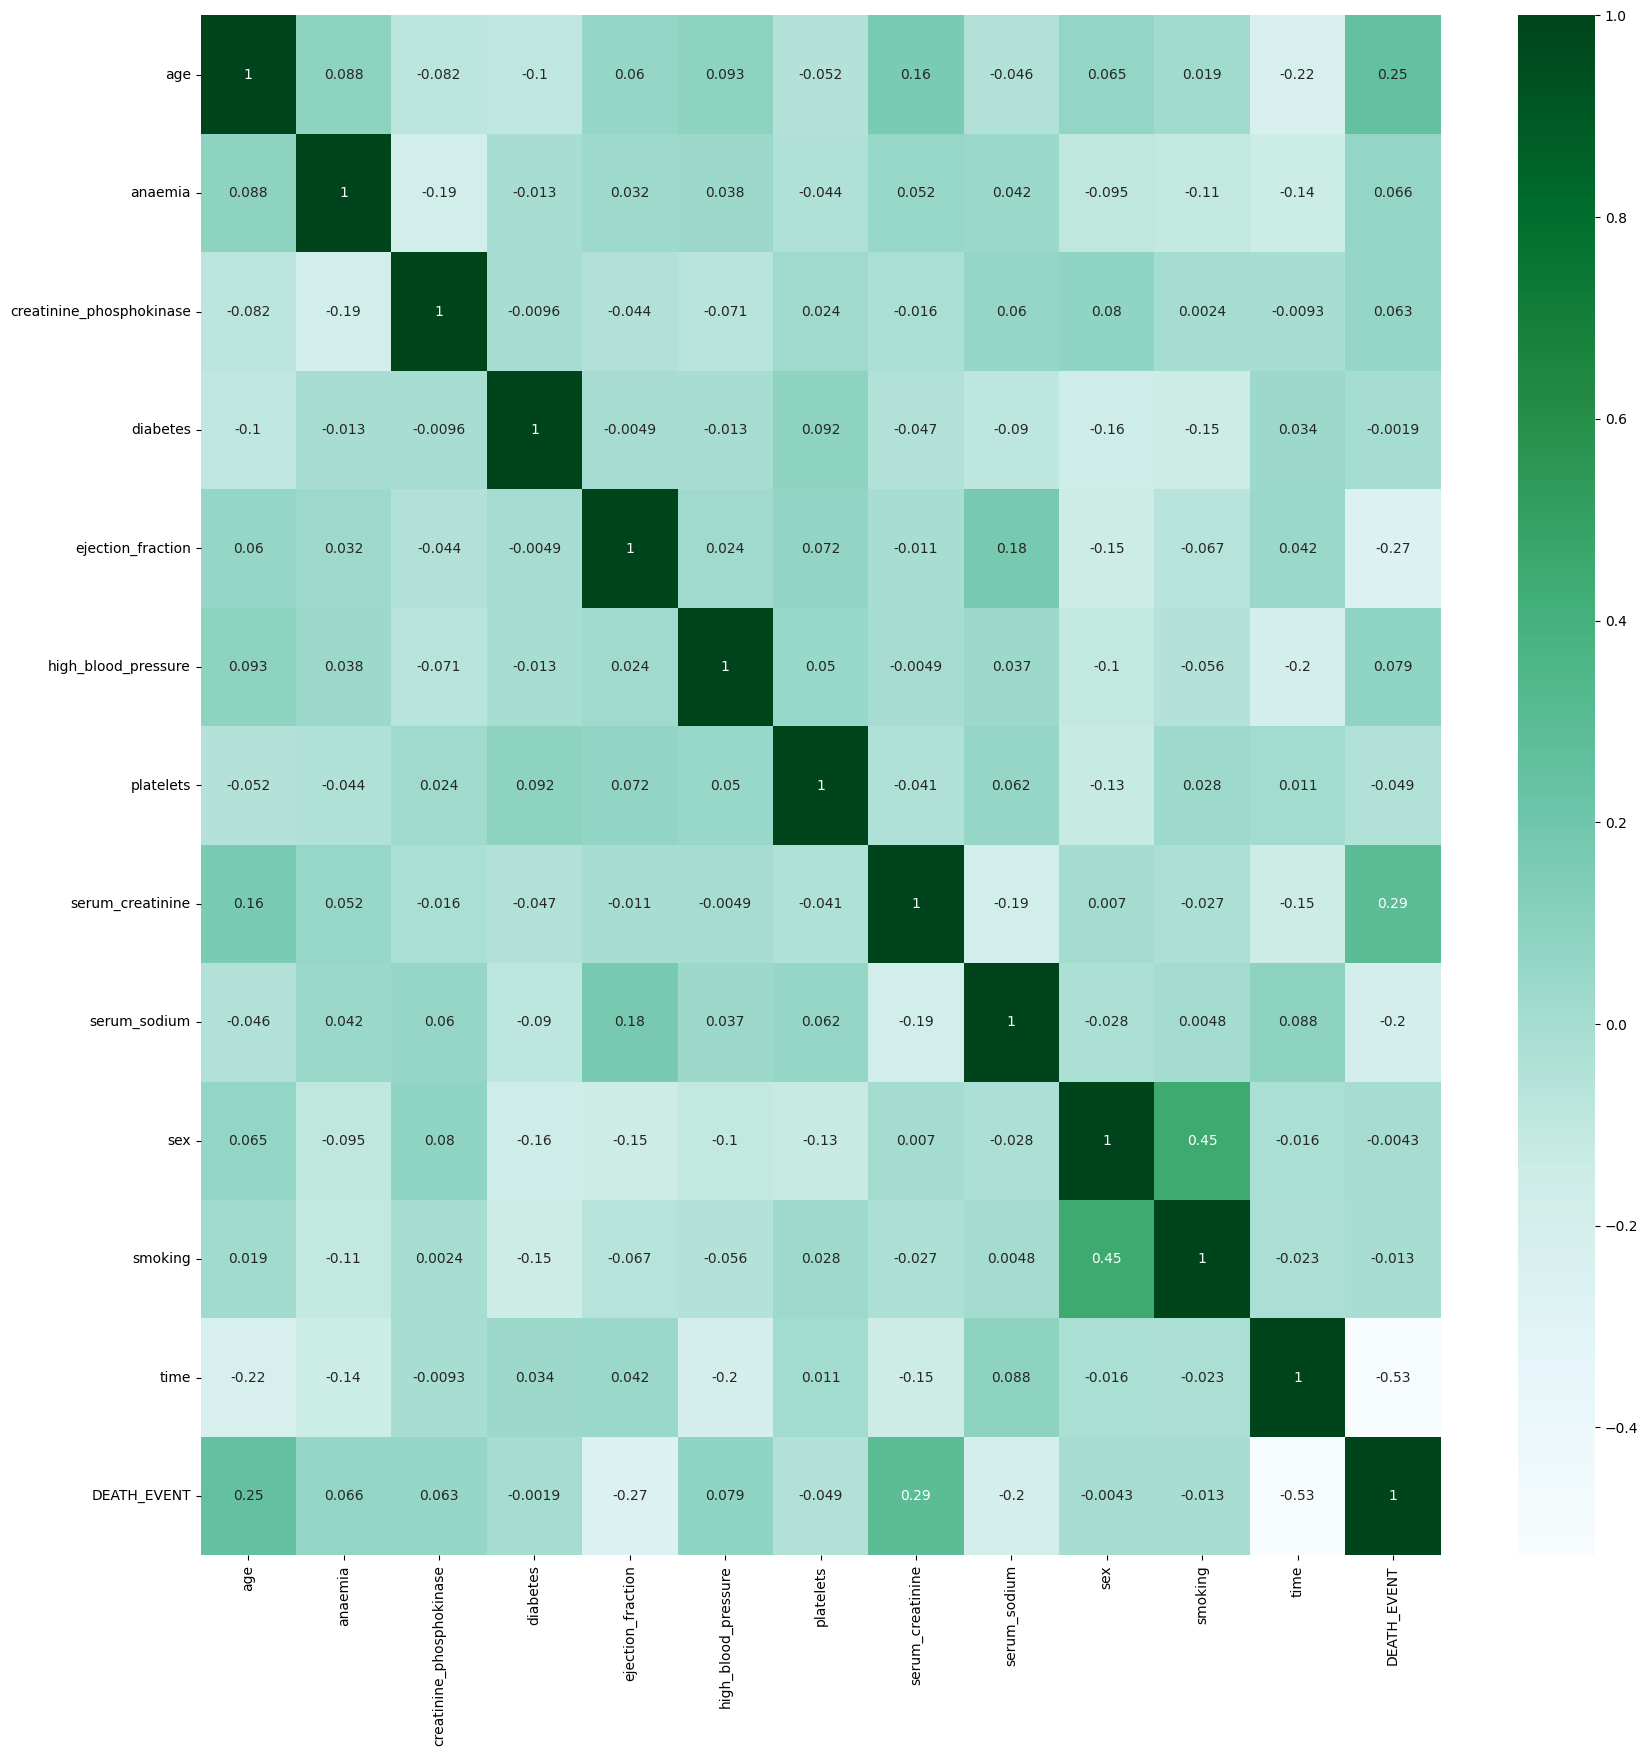

In [49]:
plt.subplots(figsize=(20,20))
sns.heatmap(data_df.corr(), cmap="BuGn", annot=True)
plt.show()

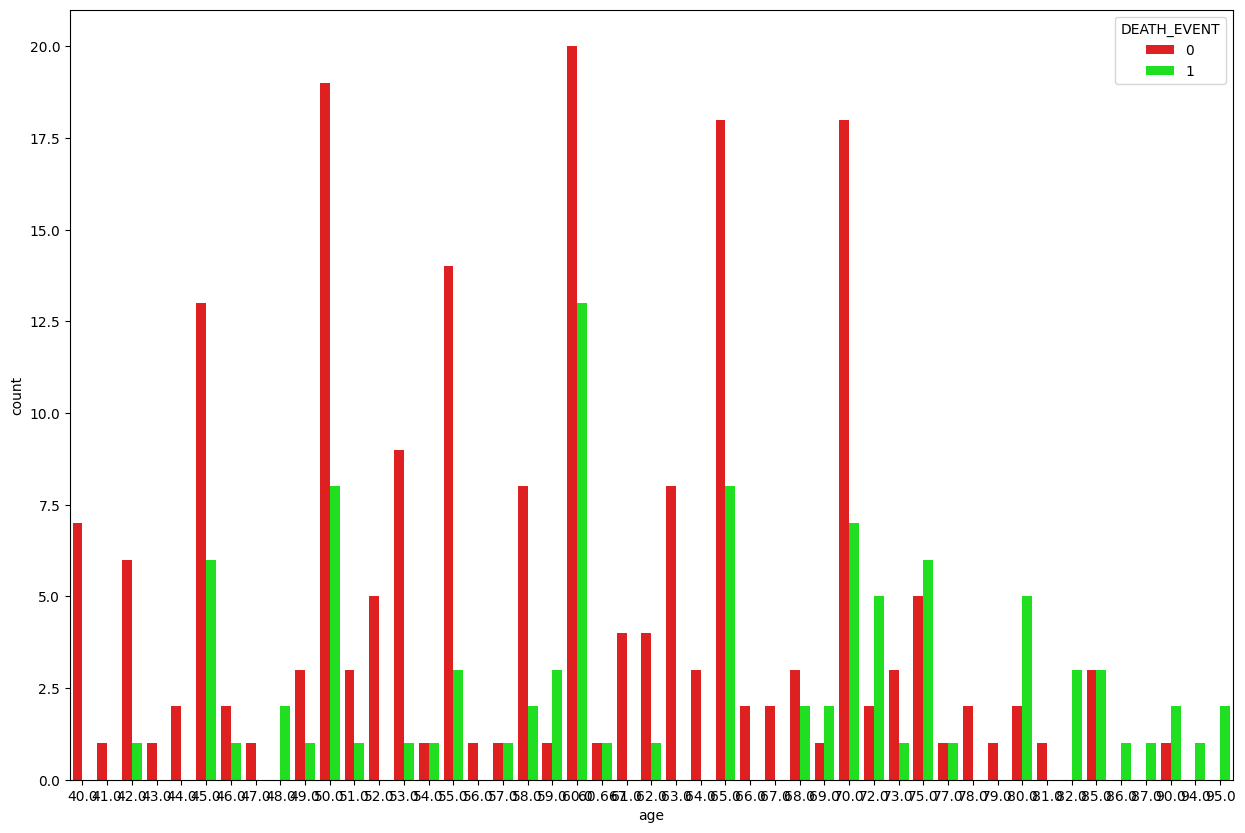

In [50]:
plt.figure(figsize=(15,10))
days_of_week = sns.countplot(x=data_df['age'],data=data_df, hue="DEATH_EVENT", palette=cols)

In [51]:
features = ["age","creatinine_phosphokinase", "ejection_fraction", "platelets", "serum_creatinine", "serum_sodium", "time"]	

/home/vani/data_science/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 13.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/vani/data_science/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 10.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


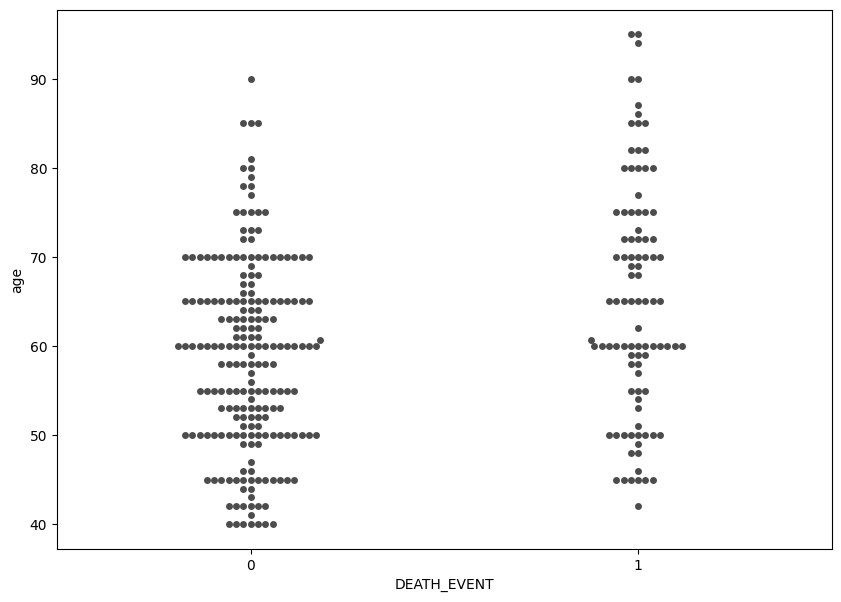

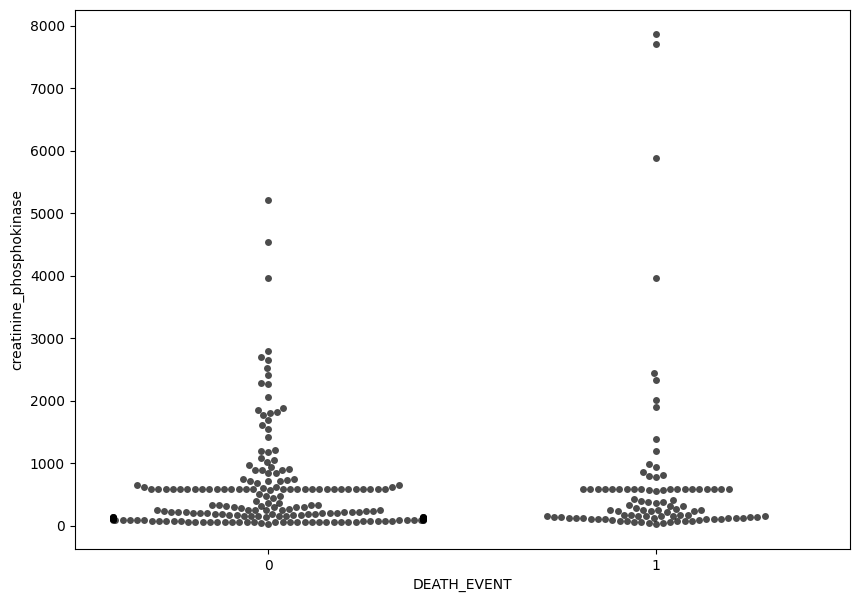

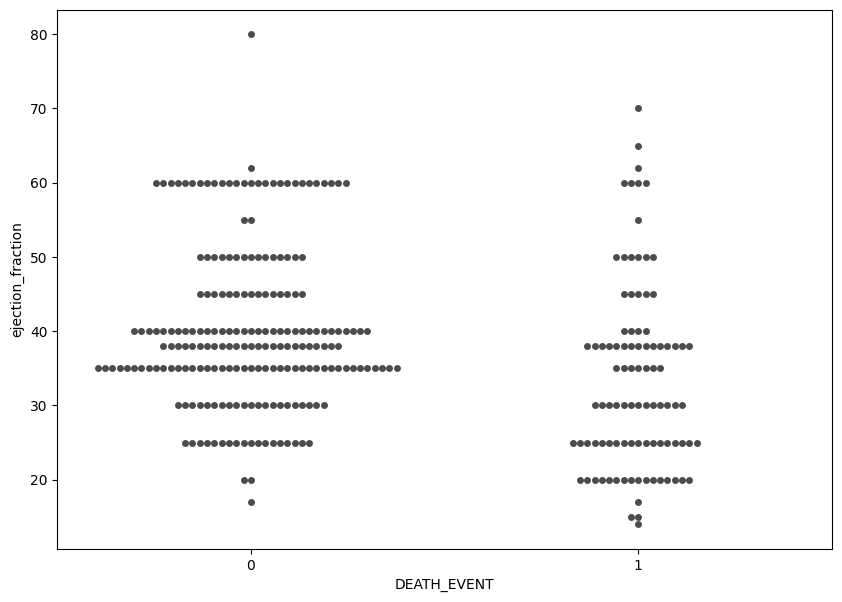

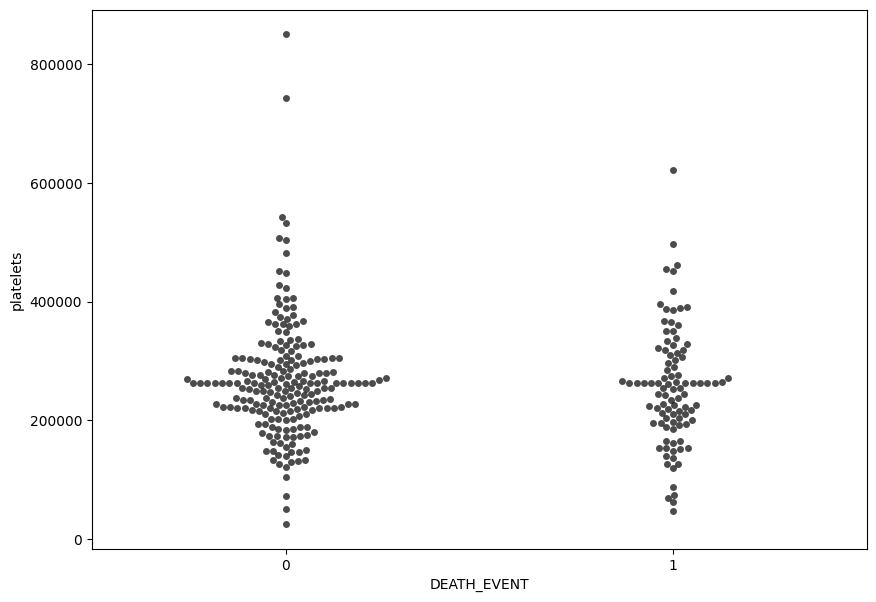

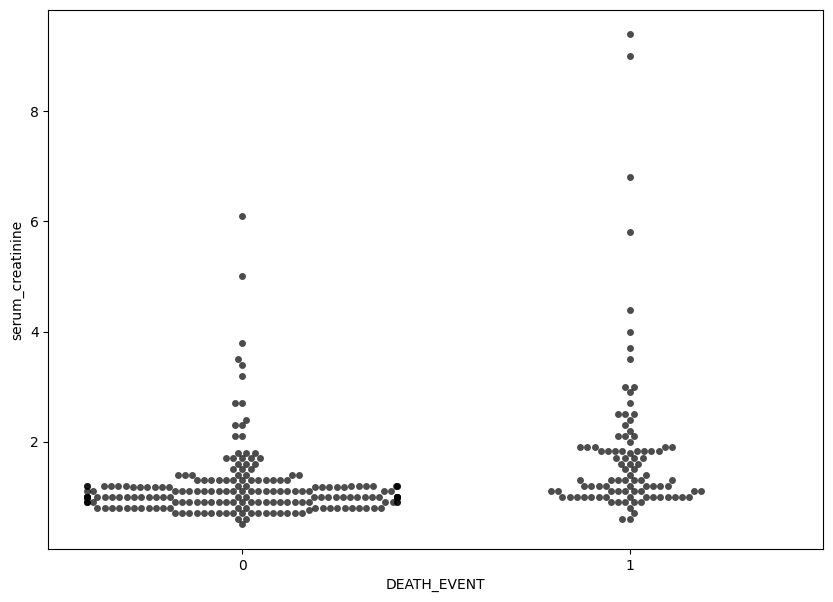

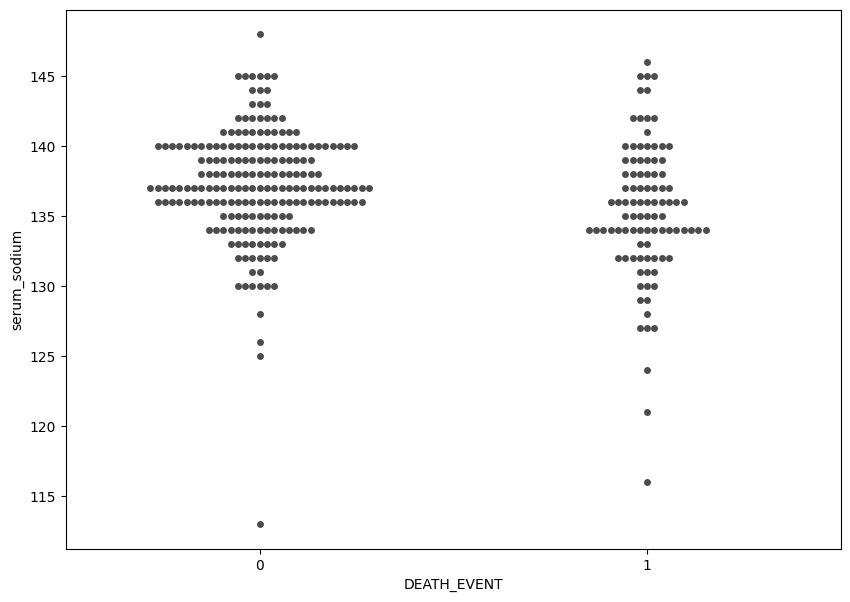

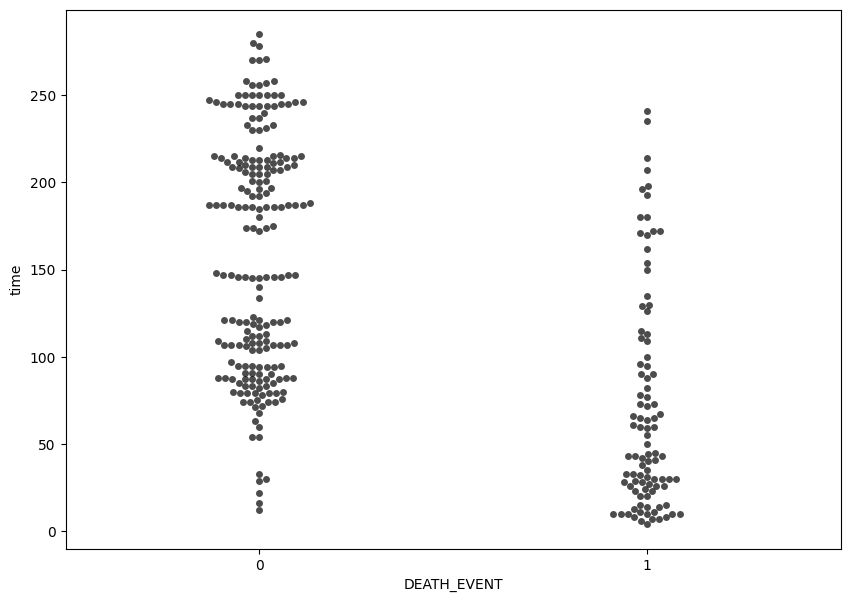

In [52]:
for i in features:
    plt.figure(figsize=(10,7))
    sns.swarmplot(x=data_df["DEATH_EVENT"], y=data_df[i], color='black',alpha=0.7)

/tmp/ipykernel_20903/2753285710.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x=data_df["DEATH_EVENT"], y=data_df[i], palette=cols)


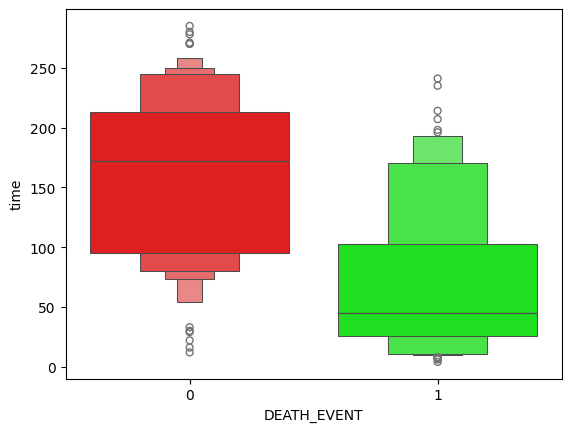

In [53]:
sns.boxenplot(x=data_df["DEATH_EVENT"], y=data_df[i], palette=cols)
plt.show()

## Step 3: Data preprocessing

In [54]:
X = data_df.drop(["DEATH_EVENT"],axis=1)
y = data_df["DEATH_EVENT"]
col_name = list(X.columns)
s_scaled = preprocessing.StandardScaler()
X_scaled = s_scaled.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled,columns=col_name)
X_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
age,299.0,5.703353e-16,1.001676,-1.754448,-0.828124,-0.070223,0.771889,2.877170
anaemia,299.0,1.009969e-16,1.001676,-0.871105,-0.871105,-0.871105,1.147968,1.147968
creatinine_phosphokinase,299.0,0.000000e+00,1.001676,-0.576918,-0.480393,-0.342574,0.000166,7.514640
diabetes,299.0,9.060014e-17,1.001676,-0.847579,-0.847579,-0.847579,1.179830,1.179830
ejection_fraction,299.0,-3.267546e-17,1.001676,-2.038387,-0.684180,-0.007077,0.585389,3.547716
high_blood_pressure,299.0,0.000000e+00,1.001676,-0.735688,-0.735688,-0.735688,1.359272,1.359272
platelets,299.0,7.723291e-17,1.001676,-2.440155,-0.520870,-0.013908,0.411120,6.008180
serum_creatinine,299.0,1.425838e-16,1.001676,-0.865509,-0.478205,-0.284552,0.005926,7.752020
serum_sodium,299.0,-8.673849e-16,1.001676,-5.363206,-0.595996,0.085034,0.766064,2.582144
sex,299.0,-8.911489e-18,1.001676,-1.359272,-1.359272,0.735688,0.735688,0.735688


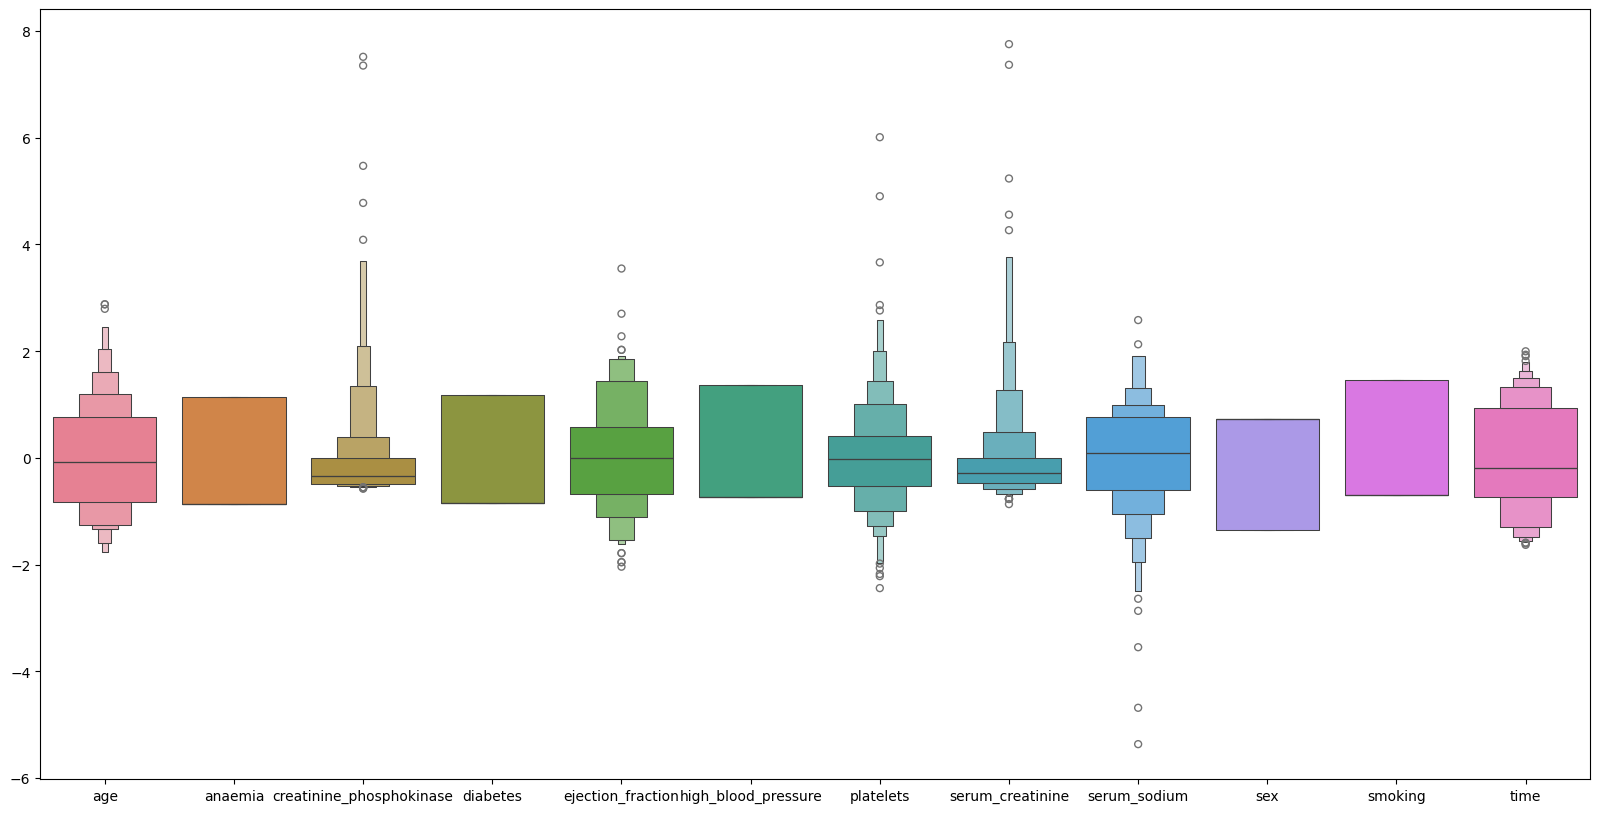

In [55]:
plt.figure(figsize=(20,10))
sns.boxenplot(data=X_scaled)
plt.show()

## Step 4: Split the data for train and test

In [56]:
X_train,X_test,y_train,y_test = train_test_split(X_scaled,y,test_size=0.3)

## Step 5: Model buliding

#### 1.SVM(support vector machine)

In [57]:
model1 = svm.SVC()
model1.fit(X_train,y_train)

SVC()

In [58]:
y_pred = model1.predict(X_test)

In [59]:
y_pred

array([0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0])

In [60]:
y_test

209    0
237    0
61     1
180    0
91     0
      ..
123    0
287    0
90     0
194    1
195    1
Name: DEATH_EVENT, Length: 90, dtype: int64

In [61]:
y_train

128    0
75     1
105    1
144    1
146    0
      ..
112    0
42     1
218    0
167    1
188    0
Name: DEATH_EVENT, Length: 209, dtype: int64

In [71]:
print(X_train.shape) 

(209, 12)


In [62]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.86      0.89      0.88        64
           1       0.71      0.65      0.68        26

    accuracy                           0.82        90
   macro avg       0.79      0.77      0.78        90
weighted avg       0.82      0.82      0.82        90



#### 2.ANN (Artifical Nerual Networks)

In [63]:
early_stopping = callbacks.EarlyStopping(min_delta = 0.0001, patience=20, restore_best_weights=True)

In [64]:
model = Sequential()

In [76]:
model = Sequential()
model.add(Dense(units=8, input_dim=12, kernel_initializer='uniform', activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(units=8, kernel_initializer='uniform', activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))  

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [77]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185 (740.00 B)

 Trainable params: 185 (740.00 B)

 Non-trainable params: 0 (0.00 B)

In [78]:
history = model.fit(
    X_train,  
    y_train,  
    batch_size=25,
    epochs=10,
    callbacks=[early_stopping],
    validation_split=0.25
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.5947 - loss: 0.6929 - val_accuracy: 0.5660 - val_loss: 0.6927
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7177 - loss: 0.6914 - val_accuracy: 0.5660 - val_loss: 0.6923
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6853 - loss: 0.6903 - val_accuracy: 0.5660 - val_loss: 0.6918
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6977 - loss: 0.6888 - val_accuracy: 0.5660 - val_loss: 0.6913
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7249 - loss: 0.6867 - val_accuracy: 0.5660 - val_loss: 0.6908
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7191 - loss: 0.6848 - val_accuracy: 0.5660 - val_loss: 0.6901
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6894 - loss: 0.6844 - val_accuracy: 0.5660 - val_loss: 0.6894
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6981 - loss: 0.6814 - val_accuracy: 0.5660 - val_loss: 0.6883


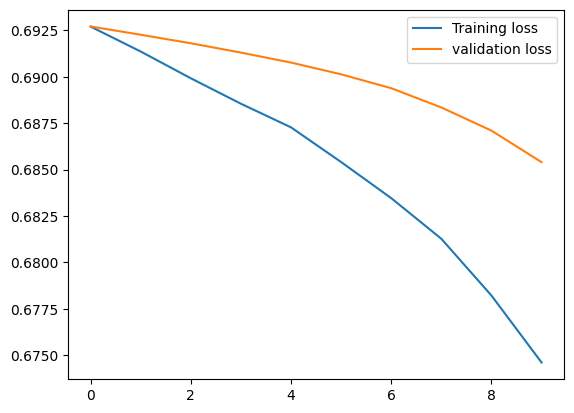

In [80]:
history_df = pd.DataFrame(history.history)
plt.plot(history_df.loc[:, ['loss']],label="Training loss")
plt.plot(history_df.loc[:, ['val_loss']],label="validation loss")
plt.legend()         
plt.show()                  

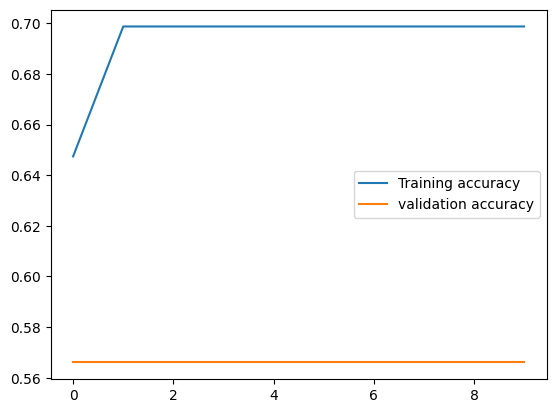

In [81]:
plt.plot(history_df.loc[:, ['accuracy']],label="Training accuracy")
plt.plot(history_df.loc[:, ['val_accuracy']],label="validation accuracy")
plt.legend()         
plt.show() 

In [82]:
y_pred = model.predict(X_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


In [84]:
y_pred = (y_pred > 0.5)

In [85]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.71      1.00      0.83        64
           1       0.00      0.00      0.00        26

    accuracy                           0.71        90
   macro avg       0.36      0.50      0.42        90
weighted avg       0.51      0.71      0.59        90



/home/vani/data_science/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/vani/data_science/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/vani/data_science/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
